# Category Intelligence — Retail Product Performance EDA
## Individual Notebook — [Bandi Ashok]

**Calibo AI Academy · Phase 1 · Mini Use Case 01 · Path 2 — KLU Batch**

| | |
|---|---|
| **Team** | 12 |
| **Member** | [Bandi Ashok] |
| **Role** | Discount & Pattern Analyst |
| **Sections owned** | Step 6.4 Discount Effectiveness · Step 6.5 Day-of-Week and Monthly Patterns |

This notebook answers two questions: is the discount programme buying any incremental volume, and when does the chain actually sell? Together they determine where promotional money should go and when it should land.

**Dataset:** `MUC01_Retail_Sales_Dataset.csv` — place it in the same folder as this notebook.
All figures here are calculated from that file and match the shared team notebook exactly.

*Role note: the assignment brief defines roles for teams of two or three. This team has four members,
so this allocation of the six required steps is our own internal split, not a structure prescribed by
the brief.*

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ---- House chart style: one palette and one labelling convention for the whole notebook ----
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (11, 6),
    "figure.dpi": 110,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

# Fixed category colours so every chart in the notebook reads the same way
CATEGORY_COLOURS = {
    "Electronics":    "#1f4e79",
    "Apparel":        "#c0504d",
    "Grocery":        "#4f8a3d",
    "Home & Kitchen": "#e08a1e",
    "Personal Care":  "#7b5ea7",
}
ACCENT = "#1f4e79"

def inr(x, decimals=2):
    """Format a rupee amount in business-readable units (Cr / L / plain)."""
    if abs(x) >= 1e7:
        return f"\u20b9{x/1e7:,.{decimals}f} Cr"
    if abs(x) >= 1e5:
        return f"\u20b9{x/1e5:,.{decimals}f} L"
    return f"\u20b9{x:,.0f}"

def rupee_axis(ax, scale=1e6, suffix=" Mn", decimals=1):
    """Apply rupee formatting to the y-axis of a chart."""
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f"\u20b9{v/scale:,.{decimals}f}{suffix}")
    )

print("Libraries loaded. Chart style set for the whole notebook.")

Libraries loaded. Chart style set for the whole notebook.


## Load the Dataset and Prepare Shared Fields

The same load-and-prepare step used in the team notebook, so this notebook runs standalone and
reproduces identical figures.

In [2]:
df = pd.read_csv("MUC01_Retail_Sales_Dataset.csv")

df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.to_period("M")
df["month_label"] = df["date"].dt.strftime("%b %Y")
df["day_of_week"] = df["date"].dt.day_name()

cat_mix = (df.groupby("category")
             .agg(Transactions=("transaction_id", "count"),
                  Units=("units_sold", "sum"),
                  Revenue=("revenue", "sum"))
             .sort_values("Revenue", ascending=False))
cat_mix["Revenue share %"] = (cat_mix["Revenue"] / cat_mix["Revenue"].sum() * 100).round(1)

monthly_category = (df.pivot_table(index="month", columns="category",
                                   values="revenue", aggfunc="sum").sort_index())
MONTH_ORDER = [p.strftime("%b %Y") for p in monthly_category.index]

print("Rows, Columns    :", df.shape)
print("Date range       :", df["date"].min().date(), "to", df["date"].max().date())
print("Categories       :", df["category"].nunique(), "| Products:", df["product_name"].nunique())
print("Null values      :", int(df.isnull().sum().sum()),
      "| Duplicate transaction IDs:", int(df["transaction_id"].duplicated().sum()))
print("Total revenue    :", inr(df["revenue"].sum()))

Rows, Columns    : (107836, 13)
Date range       : 2026-01-01 to 2026-06-30
Categories       : 5 | Products: 25
Null values      : 0 | Duplicate transaction IDs: 0
Total revenue    : ₹45.98 Cr


# Step 6.4 — Discount Effectiveness

**Owner: [Member3Name] — Discount & Pattern Analyst**

The chain is funding discounts on two-thirds of its transactions. This step asks the only question
that matters: is that money buying anything?

In [3]:
# The brief specifies brackets 0, 5, 10, 15, 20 and 25%+. We keep all six, including 25%+,
# so that an empty bracket is visibly reported rather than silently dropped.
BRACKETS = ["0%", "5%", "10%", "15%", "20%", "25%+"]
df["discount_bracket"] = pd.cut(df["discount_pct"],
                                bins=[-0.01, 0, 5, 10, 15, 20, 100],
                                labels=BRACKETS)

discount_summary = (df.groupby("discount_bracket", observed=False)
                      .agg(transactions=("transaction_id", "count"),
                           avg_revenue_per_transaction=("revenue", "mean"),
                           avg_units_sold=("units_sold", "mean"),
                           total_revenue=("revenue", "sum")))
discount_summary["share_of_transactions_%"] = (
    discount_summary["transactions"] / len(df) * 100).round(2)

print("DISCOUNT BRACKET SUMMARY")
print("Discount levels actually present in the data:", sorted(df['discount_pct'].unique()))
print("NOTE: the 25%+ bracket has 0 observations - the maximum discount in this dataset is 20%.")
print("      No values are estimated or imputed for that bracket.\n")
discount_summary.round(2)

DISCOUNT BRACKET SUMMARY
Discount levels actually present in the data: [np.int64(0), np.int64(5), np.int64(10), np.int64(15), np.int64(20)]
NOTE: the 25%+ bracket has 0 observations - the maximum discount in this dataset is 20%.
      No values are estimated or imputed for that bracket.



,transactions,avg_revenue_per_transaction,avg_units_sold,total_revenue,share_of_transactions_%
discount_bracket,,,,,
0%,36033,4685.65,2.59,1.688382e+08,33.41
5%,23922,4303.73,2.59,1.029538e+08,22.18
10%,23810,4005.55,2.57,9.537204e+07,22.08
15%,11935,4069.16,2.60,4.856548e+07,11.07
20%,12136,3631.73,2.58,4.407464e+07,11.25
25%+,0,NaN,NaN,0.000000e+00,0.00


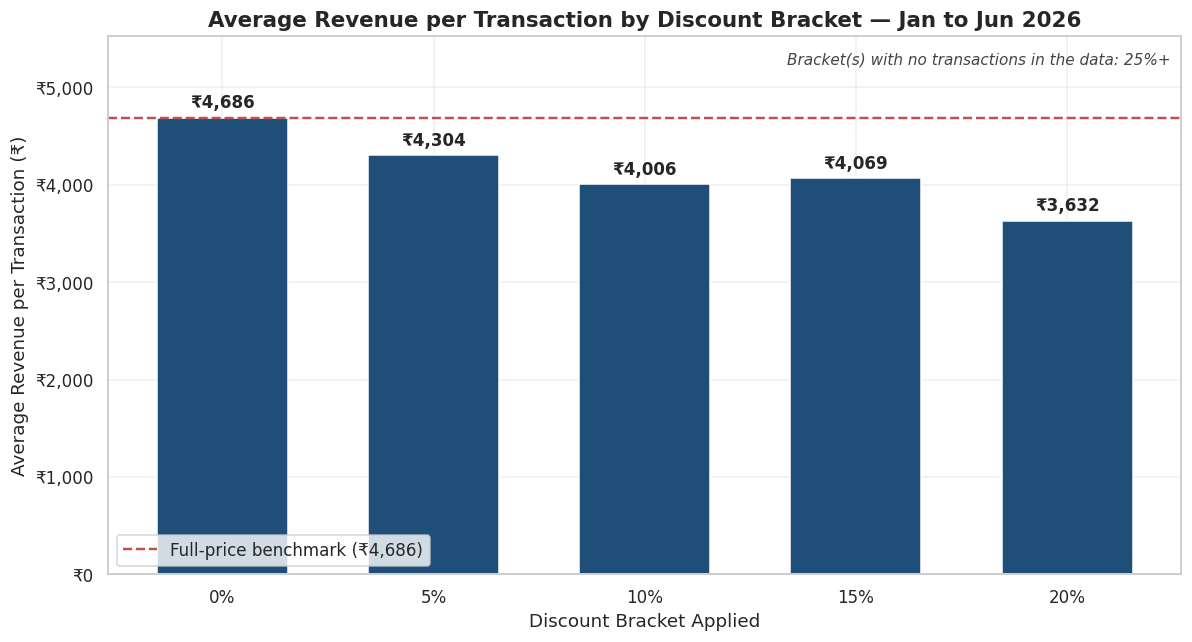

In [4]:
plot_data = discount_summary[discount_summary["transactions"] > 0]
empty_brackets = discount_summary.index[discount_summary["transactions"] == 0].tolist()

fig, ax = plt.subplots()
bars = ax.bar(plot_data.index.astype(str), plot_data["avg_revenue_per_transaction"],
              color=ACCENT, edgecolor="white", width=0.62)

for b, v in zip(bars, plot_data["avg_revenue_per_transaction"]):
    ax.text(b.get_x() + b.get_width()/2, v + 60, f"\u20b9{v:,.0f}",
            ha="center", va="bottom", fontsize=11, fontweight="bold")

baseline = plot_data["avg_revenue_per_transaction"].iloc[0]
ax.axhline(baseline, color="#c0504d", linestyle="--", linewidth=1.6,
           label=f"Full-price benchmark (\u20b9{baseline:,.0f})")

ax.set_title("Average Revenue per Transaction by Discount Bracket — Jan to Jun 2026")
ax.set_xlabel("Discount Bracket Applied")
ax.set_ylabel("Average Revenue per Transaction (\u20b9)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"\u20b9{v:,.0f}"))
ax.set_ylim(0, plot_data["avg_revenue_per_transaction"].max() * 1.18)
ax.legend(loc="lower left", frameon=True)

if empty_brackets:
    ax.text(0.99, 0.97, "Bracket(s) with no transactions in the data: " + ", ".join(empty_brackets),
            transform=ax.transAxes, ha="right", va="top", fontsize=10, style="italic", color="#444444")

plt.tight_layout()
plt.show()

In [5]:
# --- Is the fall in revenue per transaction just a category-mix effect? Control for it. ---
print("AVERAGE UNITS SOLD PER TRANSACTION, BY DISCOUNT BRACKET AND CATEGORY")
print(df.pivot_table(index="discount_bracket", columns="category",
                     values="units_sold", aggfunc="mean", observed=False).round(3).to_string())

print("\nAVERAGE REVENUE PER TRANSACTION (\u20b9), BY DISCOUNT BRACKET AND CATEGORY")
print(df.pivot_table(index="discount_bracket", columns="category",
                     values="revenue", aggfunc="mean", observed=False).round(0).to_string())

# Basket value BEFORE discount = units_sold x unit_price. If discounts pulled in bigger baskets,
# this pre-discount figure would rise with the bracket. It does not.
df["gross_basket_value"] = df["units_sold"] * df["unit_price"]
gross = df.groupby("discount_bracket", observed=False)["gross_basket_value"].mean()
print("\nAVERAGE PRE-DISCOUNT BASKET VALUE (\u20b9) BY BRACKET - tests whether discounts attract bigger baskets")
print(gross.round(2).to_string())

disc_txns = int((df["discount_pct"] > 0).sum())
print(f"\nDiscounted transactions: {disc_txns:,} of {len(df):,} ({disc_txns/len(df)*100:.1f}% of all transactions)")
print("Revenue foregone vs full list price (units x unit_price - revenue):",
      inr(df["gross_basket_value"].sum() - df["revenue"].sum()))

AVERAGE UNITS SOLD PER TRANSACTION, BY DISCOUNT BRACKET AND CATEGORY
category          Apparel  Electronics  Grocery  Home & Kitchen  Personal Care
discount_bracket                                                              
0%                  2.594        2.567    2.591           2.577          2.576
5%                  2.594        2.579    2.604           2.592          2.567
10%                 2.524        2.563    2.575           2.546          2.580
15%                 2.607        2.638    2.597           2.610          2.573
20%                 2.580        2.627    2.579           2.622          2.569

AVERAGE REVENUE PER TRANSACTION (₹), BY DISCOUNT BRACKET AND CATEGORY
category          Apparel  Electronics  Grocery  Home & Kitchen  Personal Care
discount_bracket                                                              
0%                 4918.0      61151.0    844.0         10635.0         1645.0
5%                 4633.0      57388.0    801.0          9851.0       

### Our position: the discount programme is not working — [Member3Name]

**What happened.** Average revenue per transaction falls **monotonically as the discount rises**:
**₹4,685.65 at 0%**, ₹4,303.73 at 5%, ₹4,005.55 at 10%, ₹4,069.16 at 15% and **₹3,631.73 at 20%** —
**22.5% lower at the deepest discount than at full price**. Meanwhile average units sold is
**effectively flat across every bracket: 2.59, 2.59, 2.57, 2.60, 2.58**, a total spread of 0.03 units.
The **25%+ bracket contains zero transactions** — the maximum discount in this dataset is 20% — so
nothing is reported for it.

**And it is not a category-mix illusion.** Controlling for category, average units per transaction is
flat inside *every* category (Grocery 2.59 at 0% vs 2.58 at 20%; Electronics 2.57 vs 2.63; Apparel
2.59 vs 2.58), while revenue per transaction falls within every category as the discount deepens
(Home & Kitchen ₹10,635 → ₹8,608; Personal Care ₹1,645 → ₹1,302). The sharpest test: **average
pre-discount basket value is flat across brackets** (₹4,685 at 0%, ₹4,530 at 5%, ₹4,451 at 10%,
₹4,787 at 15%, ₹4,540 at 20%). If discounts were pulling in larger baskets, that number would climb
with the bracket. It does not.

**Our position, stated plainly.** Discounts in this dataset are **not generating incremental volume**.
They are changing the realised price on baskets the chain appears to have been selling anyway.
**66.6% of transactions (71,803 of 107,836) carry a discount**, and the gap between list value and
realised revenue across the period is **₹3.56 Cr**.

**The limitation, stated just as plainly.** This dataset contains `revenue` *after* discount and
carries **no cost, COGS or margin column**. We therefore **cannot and do not claim a measured margin
impact**. What we can say from the available evidence — revenue per transaction, units per
transaction, transaction counts and pre-discount basket value — is that the volume response the
discount is supposed to buy does not appear in the data. Whether the ₹3.56 Cr of foregone list value
translates into a proportionate margin loss can only be confirmed with cost data (see Step 6.6).

**What action this suggests.** Put the discount ladder itself on the supplier-review agenda: propose
a controlled test that withdraws 15% and 20% discounts in a subset of stores for one quarter and
measures the unit response, and redirect the funding toward the categories where the trend analysis
shows demand is already moving.

---

# Step 6.5 — Day-of-Week and Monthly Patterns

**Owner: [Member3Name] — Discount & Pattern Analyst**

Trend and product analysis tell the Category Manager *what* to promote. Timing analysis tells her
*when*.

In [6]:
DAY_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df["day_of_week"] = df["date"].dt.day_name()

daily_totals = df.groupby("date", as_index=False)["revenue"].sum()
daily_totals["day_of_week"] = daily_totals["date"].dt.day_name()

dow_chain = (daily_totals.groupby("day_of_week")["revenue"]
             .agg(avg_daily_revenue="mean", days_observed="count")
             .reindex(DAY_ORDER))
dow_chain["Index vs average day (100 = avg)"] = (
    dow_chain["avg_daily_revenue"] / dow_chain["avg_daily_revenue"].mean() * 100).round(1)

print("AVERAGE DAILY REVENUE BY DAY OF WEEK - WHOLE CHAIN")
dow_chain.round(2)

AVERAGE DAILY REVENUE BY DAY OF WEEK - WHOLE CHAIN


,avg_daily_revenue,days_observed,Index vs average day (100 = avg)
day_of_week,,,
Monday,2012140.96,26,79.3
Tuesday,2054129.70,26,80.9
Wednesday,2228117.24,25,87.8
Thursday,2245493.02,26,88.5
Friday,2623611.89,26,103.3
Saturday,3523605.44,26,138.8
Sunday,3083374.58,26,121.5


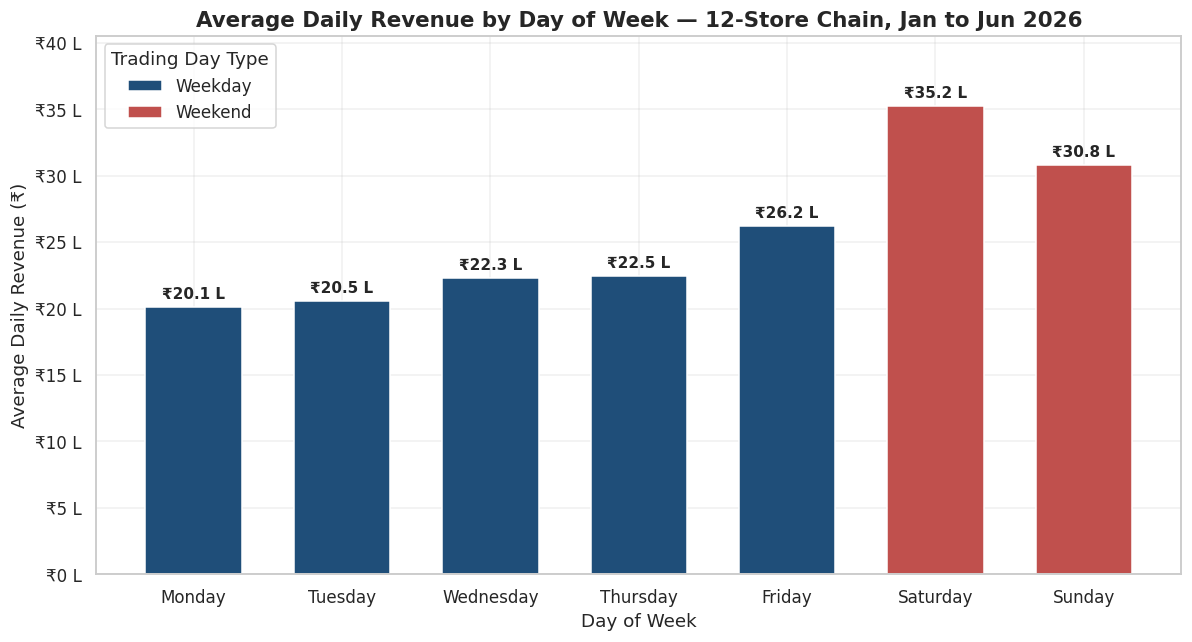

In [7]:
fig, ax = plt.subplots()
colors = [ACCENT if d not in ("Saturday", "Sunday") else "#c0504d" for d in DAY_ORDER]
bars = ax.bar(DAY_ORDER, dow_chain["avg_daily_revenue"], color=colors, edgecolor="white", width=0.65)
for b, v in zip(bars, dow_chain["avg_daily_revenue"]):
    ax.text(b.get_x() + b.get_width()/2, v + 40000, f"\u20b9{v/1e5:,.1f} L",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_title("Average Daily Revenue by Day of Week — 12-Store Chain, Jan to Jun 2026")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Average Daily Revenue (\u20b9)")
rupee_axis(ax, scale=1e5, suffix=" L", decimals=0)
ax.set_ylim(0, dow_chain["avg_daily_revenue"].max() * 1.15)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=ACCENT, label="Weekday"),
                   Patch(facecolor="#c0504d", label="Weekend")],
          title="Trading Day Type", loc="upper left", frameon=True)
plt.tight_layout()
plt.show()

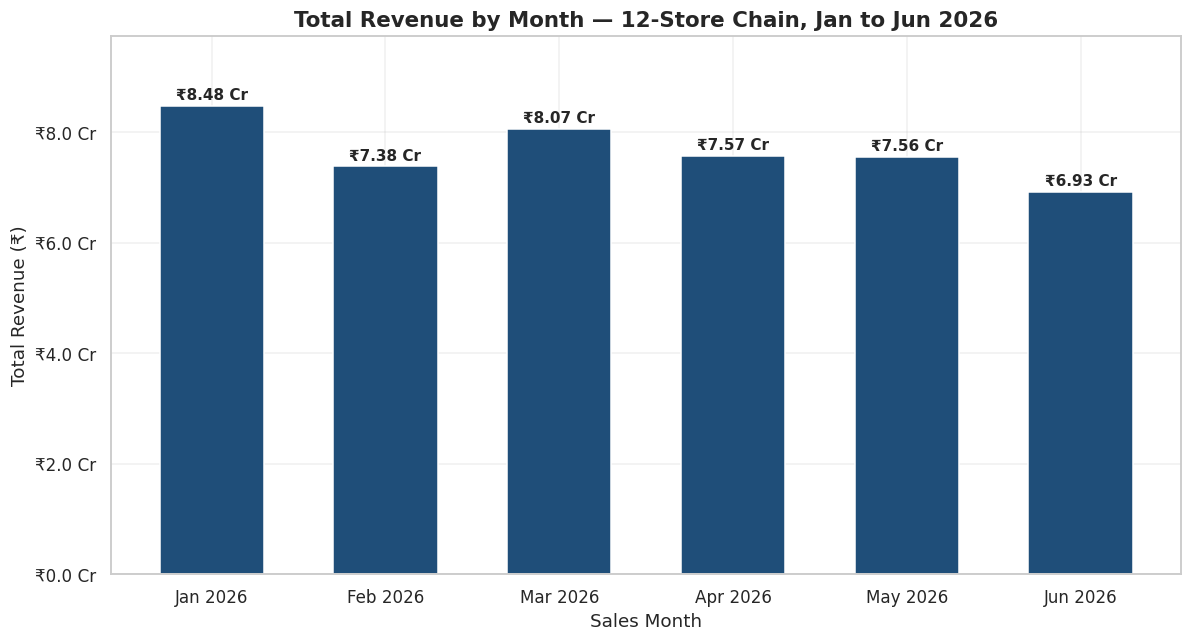

In [8]:
monthly_chain = df.groupby("month")["revenue"].sum()
monthly_chain.index = MONTH_ORDER

fig, ax = plt.subplots()
bars = ax.bar(monthly_chain.index, monthly_chain.values, color=ACCENT, edgecolor="white", width=0.6)
for b, v in zip(bars, monthly_chain.values):
    ax.text(b.get_x() + b.get_width()/2, v + 600000, f"\u20b9{v/1e7:,.2f} Cr",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_title("Total Revenue by Month — 12-Store Chain, Jan to Jun 2026")
ax.set_xlabel("Sales Month")
ax.set_ylabel("Total Revenue (\u20b9)")
rupee_axis(ax, scale=1e7, suffix=" Cr", decimals=1)
ax.set_ylim(0, monthly_chain.max() * 1.15)
plt.tight_layout()
plt.show()

In [9]:
best_day, worst_day = dow_chain["avg_daily_revenue"].idxmax(), dow_chain["avg_daily_revenue"].idxmin()
best_month, worst_month = monthly_chain.idxmax(), monthly_chain.idxmin()

print("CHAIN-LEVEL PEAKS AND TROUGHS")
print(f"Best day    : {best_day:<10} {inr(dow_chain['avg_daily_revenue'].max())} average per day")
print(f"Worst day   : {worst_day:<10} {inr(dow_chain['avg_daily_revenue'].min())} average per day")
print(f"  Saturday earns {dow_chain['avg_daily_revenue'].max()/dow_chain['avg_daily_revenue'].min():.2f}x a Monday")
print(f"Best month  : {best_month:<10} {inr(monthly_chain.max())}")
print(f"Worst month : {worst_month:<10} {inr(monthly_chain.min())}")

weekend = daily_totals["day_of_week"].isin(["Saturday", "Sunday"])
print(f"\nWeekend average day : {inr(daily_totals.loc[weekend, 'revenue'].mean())}")
print(f"Weekday average day : {inr(daily_totals.loc[~weekend, 'revenue'].mean())}")
print(f"Weekend uplift      : {(daily_totals.loc[weekend,'revenue'].mean()/daily_totals.loc[~weekend,'revenue'].mean()-1)*100:.1f}%")

CHAIN-LEVEL PEAKS AND TROUGHS
Best day    : Saturday   ₹35.24 L average per day
Worst day   : Monday     ₹20.12 L average per day
  Saturday earns 1.75x a Monday
Best month  : Jan 2026   ₹8.48 Cr
Worst month : Jun 2026   ₹6.93 Cr

Weekend average day : ₹33.03 L
Weekday average day : ₹22.33 L
Weekend uplift      : 48.0%


In [10]:
# --- The single most interesting category from Step 6.2: Electronics ---
# Chosen because it is 49.3% of chain revenue AND the steepest decliner (-35.02%).
FOCUS = "Electronics"
focus_df = df[df["category"] == FOCUS]

focus_daily = focus_df.groupby("date", as_index=False)["revenue"].sum()
focus_daily["day_of_week"] = focus_daily["date"].dt.day_name()
focus_dow = focus_daily.groupby("day_of_week")["revenue"].mean().reindex(DAY_ORDER)

comparison = pd.DataFrame({
    "Chain index (100 = its average day)": (dow_chain["avg_daily_revenue"] / dow_chain["avg_daily_revenue"].mean() * 100).round(1),
    f"{FOCUS} index (100 = its average day)": (focus_dow / focus_dow.mean() * 100).round(1),
})
comparison["Gap (pts)"] = (comparison.iloc[:, 1] - comparison.iloc[:, 0]).round(1)

print(f"DAY-OF-WEEK SHAPE: WHOLE CHAIN vs {FOCUS.upper()} (indexed so the two are directly comparable)")
print(comparison.to_string())
print(f"\n{FOCUS} best day : {focus_dow.idxmax()} ({inr(focus_dow.max())} average per day)")
print(f"{FOCUS} worst day: {focus_dow.idxmin()} ({inr(focus_dow.min())} average per day)")

focus_monthly = focus_df.groupby("month")["revenue"].sum()
focus_monthly.index = MONTH_ORDER
print(f"\n{FOCUS} best month : {focus_monthly.idxmax()} ({inr(focus_monthly.max())})")
print(f"{FOCUS} worst month: {focus_monthly.idxmin()} ({inr(focus_monthly.min())})")

DAY-OF-WEEK SHAPE: WHOLE CHAIN vs ELECTRONICS (indexed so the two are directly comparable)
             Chain index (100 = its average day)  Electronics index (100 = its average day)  Gap (pts)
day_of_week                                                                                           
Monday                                      79.3                                       77.6       -1.7
Tuesday                                     80.9                                       78.0       -2.9
Wednesday                                   87.8                                       88.9        1.1
Thursday                                    88.5                                       84.9       -3.6
Friday                                     103.3                                      103.2       -0.1
Saturday                                   138.8                                      142.8        4.0
Sunday                                     121.5                                     

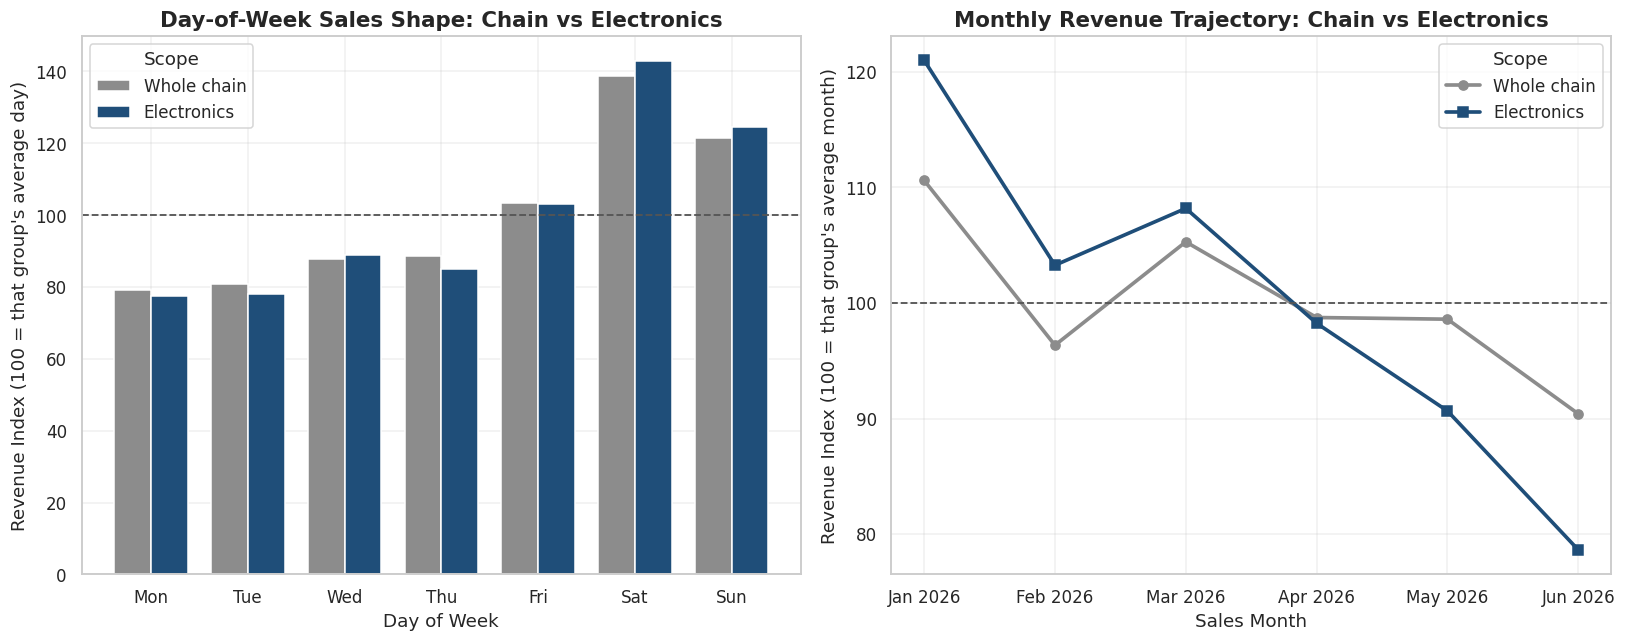

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

x = np.arange(len(DAY_ORDER)); w = 0.38
NEUTRAL = "#8c8c8c"   # whole chain drawn in neutral grey so the focus category stands out
ax1.bar(x - w/2, comparison["Chain index (100 = its average day)"], width=w,
        color=NEUTRAL, edgecolor="white", label="Whole chain")
ax1.bar(x + w/2, comparison[f"{FOCUS} index (100 = its average day)"], width=w,
        color=CATEGORY_COLOURS[FOCUS], edgecolor="white", label=FOCUS)
ax1.axhline(100, color="#555555", linestyle="--", linewidth=1.2)
ax1.set_title(f"Day-of-Week Sales Shape: Chain vs {FOCUS}")
ax1.set_xlabel("Day of Week")
ax1.set_ylabel("Revenue Index (100 = that group's average day)")
ax1.set_xticks(x); ax1.set_xticklabels([d[:3] for d in DAY_ORDER])
ax1.legend(title="Scope", frameon=True)

chain_idx = monthly_chain / monthly_chain.mean() * 100
focus_idx = focus_monthly / focus_monthly.mean() * 100
ax2.plot(MONTH_ORDER, chain_idx.values, marker="o", linewidth=2.4, color=NEUTRAL, label="Whole chain")
ax2.plot(MONTH_ORDER, focus_idx.values, marker="s", linewidth=2.4,
         color=CATEGORY_COLOURS[FOCUS], label=FOCUS)
ax2.axhline(100, color="#555555", linestyle="--", linewidth=1.2)
ax2.set_title(f"Monthly Revenue Trajectory: Chain vs {FOCUS}")
ax2.set_xlabel("Sales Month")
ax2.set_ylabel("Revenue Index (100 = that group's average month)")
ax2.legend(title="Scope", frameon=True)

plt.tight_layout()
plt.show()

### What the timing analysis means — [Bandi Ashok]

**What happened — chain level.** Revenue is heavily weekend-loaded. **Saturday is the best day at an
average ₹35.24 L, Monday the worst at ₹20.12 L** — Saturday earns **1.75× a Monday**, and the average
weekend day runs **48.0% ahead of the average weekday**. By month, **January was the best at ₹8.48 Cr
and June the worst at ₹6.93 Cr**, an 18.3% decline across the half-year with no recovery month.

**The most interesting category is Electronics** — it is 49.3% of chain revenue and the steepest
decliner (−35.02%), so it drives both patterns.

**Does it follow the chain?** On day of week, **it follows the chain's shape but amplifies it**.
Indexed against its own average day, Electronics reads Saturday **142.8** vs the chain's 138.8 and
Monday **77.6** vs the chain's 79.3 — the same weekend peak and Monday trough, only steeper. Its best
and worst days are identical to the chain's (Saturday ₹17.87 L, Monday ₹9.71 L). **On the monthly
trajectory it behaves very differently**: the chain falls 18.3% Jan→Jun while Electronics falls
35.02%, so Electronics is not riding a general chain slowdown — it is causing most of it, and the two
lines diverge steadily from March onward.

**What this means for promotional timing.** Promotional weight should be concentrated where demand
already exists — Friday through Sunday, and in Electronics especially, where the weekend skew is
sharpest — rather than spent trying to manufacture a Monday or Tuesday that has never performed.
Because Step 6.4 shows discounts move price rather than units, the more defensible lever for the weak
Monday–Thursday window is non-price activity (availability, staffing, in-store demonstration) rather
than deeper markdowns. And because Electronics' monthly decline runs at roughly twice the chain's,
its promotional calendar should be rebuilt around a recovery plan with a measurable June-exit run
rate rather than around seasonal peaks the category is no longer reaching.

---